# MWE 10 - Simplified 2D lattice-based vug sensitivity

This notebook is a simplified 2D analogue of MWE 09.

Study design:

- Start from 2D Cartesian lattice networks (`x-y`, with finite slab thickness).
- Build multiple stochastic baseline realizations via pore/throat radius perturbations.
- Insert one vug super-pore by replacing an elliptical pore subset and reconnecting interface pores.
- Compare porosity and `Kabs` response for:
  - circular vugs,
  - flow-stretched ellipses,
  - orthogonally stretched ellipses.

Caveats:

- This is a synthetic PNM surrogate, not DNS or image-derived truth.
- Interface throat sizing around the vug is heuristic and affects `K`.
- Geometry perturbations are i.i.d. (no spatial correlation).


In [12]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    from tqdm.auto import tqdm as _tqdm
except Exception:  # pragma: no cover
    _tqdm = None

from voids.core.network import Network
from voids.examples import make_cartesian_mesh_network
from voids.graph.connectivity import induced_subnetwork
from voids.graph.metrics import coordination_numbers
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.visualization import plot_network_plotly

CIRCULAR_SHAPE_FACTOR = 1.0 / (4.0 * np.pi)

In [13]:
def iter_progress(
    iterable,
    *,
    desc: str | None = None,
    total: int | None = None,
    enabled: bool = True,
    leave: bool = False,
):
    """Wrap iterable with tqdm when available."""

    if not enabled or _tqdm is None:
        return iterable
    return _tqdm(
        iterable,
        desc=desc,
        total=total,
        dynamic_ncols=True,
        leave=leave,
    )

In [14]:
# Study controls
FLOW_AXIS = "x"
MESH_SHAPE_2D = (36, 36)
SPACING_M = 40.0e-6
THICKNESS_M = 40.0e-6

BASE_PORE_RADIUS_M = 0.22 * SPACING_M
BASE_THROAT_RADIUS_M = 0.11 * SPACING_M

N_BASELINES = 10
BASE_SEED = 20260305
PORE_RADIUS_REL_STD = 0.09
THROAT_RADIUS_REL_STD = 0.11

# Five configurations per family
EQUIV_RADII_SPACING = [1.1, 1.4, 1.7, 2.0, 2.3]
ELLIPSOID_ASPECT = 1.8

PLOTLY_MAX_THROATS_BASELINE = 2000
PLOTLY_MAX_THROATS_VUG: int | None = None  # keep all vug connections visible
PLOTLY_LAYOUT = {"width": 900, "height": 620}
PLOTLY_SIZE_LIMITS = (None, None)

USE_TQDM = os.environ.get("VOIDS_DISABLE_TQDM", "0") != "1"
SMOKE_MODE = os.environ.get("VOIDS_VUG_SMOKE", "0") == "1"
if SMOKE_MODE:
    N_BASELINES = 2
    EQUIV_RADII_SPACING = EQUIV_RADII_SPACING[:2]

print("shape_2d:", MESH_SHAPE_2D)
print("spacing [m]:", SPACING_M, "| thickness [m]:", THICKNESS_M)
print("flow axis:", FLOW_AXIS)
print("baseline realizations:", N_BASELINES)
print("equivalent radius levels:", EQUIV_RADII_SPACING)

shape_2d: (36, 36)
spacing [m]: 4e-05 | thickness [m]: 4e-05
flow axis: x
baseline realizations: 10
equivalent radius levels: [1.1, 1.4, 1.7, 2.0, 2.3]


In [15]:
def equivalent_radius_2d(radii_xy: tuple[float, float]) -> float:
    """Area-equivalent circular radius for an ellipse with radii (rx, ry)."""

    rx, ry = radii_xy
    return float(np.sqrt(rx * ry))

def _format_radius_token(value: float) -> str:
    """Return stable filename-safe token for radius values."""

    return f"{value:.2f}".replace(".", "p")

def sample_depth(net: Network) -> float:
    """Infer slab thickness for a 2D mesh network."""

    if "z" in net.sample.lengths:
        return float(net.sample.lengths["z"])
    lx = float(net.sample.length_for_axis("x"))
    ly = float(net.sample.length_for_axis("y"))
    bulk = float(net.sample.resolved_bulk_volume())
    return float(bulk / max(lx * ly, 1.0e-30))

def _ellipse_mask_2d(
    coords: np.ndarray,
    *,
    center_xy: tuple[float, float],
    radii_xy: tuple[float, float],
) -> np.ndarray:
    """Return mask selecting pores inside an axis-aligned 2D ellipse."""

    cx, cy = center_xy
    rx, ry = (float(radii_xy[0]), float(radii_xy[1]))
    if min(rx, ry) <= 0:
        raise ValueError("Ellipse radii must be strictly positive")
    dx = (coords[:, 0] - cx) / rx
    dy = (coords[:, 1] - cy) / ry
    return (dx * dx + dy * dy) <= 1.0

def update_network_geometry_2d(
    net: Network,
    *,
    pore_radius: np.ndarray,
    throat_radius: np.ndarray,
    depth: float,
) -> None:
    """Update pore/throat geometry fields for a 2D slab-like mesh network."""

    pore_radius = np.asarray(pore_radius, dtype=float)
    throat_radius = np.asarray(throat_radius, dtype=float)
    if pore_radius.shape != (net.Np,):
        raise ValueError(f"pore_radius must have shape ({net.Np},)")
    if throat_radius.shape != (net.Nt,):
        raise ValueError(f"throat_radius must have shape ({net.Nt},)")

    pore_area = np.pi * pore_radius**2
    pore_perimeter = 2.0 * np.pi * pore_radius
    pore_volume = pore_area * depth

    net.pore["radius_inscribed"] = pore_radius
    net.pore["diameter_inscribed"] = 2.0 * pore_radius
    net.pore["area"] = pore_area
    net.pore["perimeter"] = pore_perimeter
    net.pore["volume"] = pore_volume
    net.pore["shape_factor"] = np.full(net.Np, CIRCULAR_SHAPE_FACTOR, dtype=float)

    conns = np.asarray(net.throat_conns, dtype=int)
    c0 = net.pore_coords[conns[:, 0]]
    c1 = net.pore_coords[conns[:, 1]]
    direct_length = np.linalg.norm(c1 - c0, axis=1)

    p1_length = np.minimum(pore_radius[conns[:, 0]], 0.45 * direct_length)
    p2_length = np.minimum(pore_radius[conns[:, 1]], 0.45 * direct_length)
    core_length = np.maximum(
        direct_length - p1_length - p2_length,
        0.05 * direct_length,
    )

    throat_area = np.pi * throat_radius**2
    throat_perimeter = 2.0 * np.pi * throat_radius
    throat_volume = throat_area * core_length

    net.throat["radius_inscribed"] = throat_radius
    net.throat["diameter_inscribed"] = 2.0 * throat_radius
    net.throat["area"] = throat_area
    net.throat["perimeter"] = throat_perimeter
    net.throat["shape_factor"] = np.full(net.Nt, CIRCULAR_SHAPE_FACTOR, dtype=float)
    net.throat["length"] = direct_length
    net.throat["direct_length"] = direct_length
    net.throat["pore1_length"] = p1_length
    net.throat["core_length"] = core_length
    net.throat["pore2_length"] = p2_length
    net.throat["volume"] = throat_volume

def generate_baseline_network(*, baseline_id: int, seed: int) -> Network:
    """Build one stochastic 2D baseline network realization."""

    net = make_cartesian_mesh_network(
        MESH_SHAPE_2D,
        spacing=SPACING_M,
        thickness=THICKNESS_M,
        pore_radius=BASE_PORE_RADIUS_M,
        throat_radius=BASE_THROAT_RADIUS_M,
        units={"length": "m", "pressure": "Pa"},
    )

    rng = np.random.default_rng(seed)
    pore_factor = np.clip(
        rng.normal(loc=1.0, scale=PORE_RADIUS_REL_STD, size=net.Np),
        0.65,
        1.40,
    )
    throat_factor = np.clip(
        rng.normal(loc=1.0, scale=THROAT_RADIUS_REL_STD, size=net.Nt),
        0.60,
        1.45,
    )

    update_network_geometry_2d(
        net,
        pore_radius=BASE_PORE_RADIUS_M * pore_factor,
        throat_radius=BASE_THROAT_RADIUS_M * throat_factor,
        depth=THICKNESS_M,
    )

    net.extra["baseline_id"] = int(baseline_id)
    net.extra["baseline_seed"] = int(seed)
    return net

def insert_vug_superpore_2d(
    net: Network,
    *,
    radii_xy: tuple[float, float],
    center_xy: tuple[float, float] | None = None,
) -> tuple[Network, dict[str, object]]:
    """Replace a 2D ellipse pore subset by one vug super-pore and reconnect."""

    base = net.copy()
    coords = np.asarray(base.pore_coords, dtype=float)

    if center_xy is None:
        center_xy = (
            float(0.5 * (coords[:, 0].min() + coords[:, 0].max())),
            float(0.5 * (coords[:, 1].min() + coords[:, 1].max())),
        )

    inside = _ellipse_mask_2d(coords, center_xy=center_xy, radii_xy=radii_xy)
    if not np.any(inside):
        nearest = int(
            np.argmin(
                (coords[:, 0] - center_xy[0]) ** 2 + (coords[:, 1] - center_xy[1]) ** 2
            )
        )
        inside[nearest] = True

    conns = np.asarray(base.throat_conns, dtype=int)
    ci = inside[conns[:, 0]]
    cj = inside[conns[:, 1]]

    outside_neighbors = np.unique(
        np.concatenate([conns[ci & (~cj), 1], conns[(~ci) & cj, 0]])
    )
    if outside_neighbors.size == 0:
        raise RuntimeError("Vug insertion produced zero interface neighbors")

    keep_mask = ~inside
    subnet, kept_old_idx, _ = induced_subnetwork(base, keep_mask)

    old_to_new = -np.ones(base.Np, dtype=int)
    old_to_new[kept_old_idx] = np.arange(kept_old_idx.size, dtype=int)
    boundary_new = old_to_new[outside_neighbors]
    boundary_new = np.unique(boundary_new[boundary_new >= 0])
    if boundary_new.size == 0:
        raise RuntimeError(
            "No interface pores remained after induced-subnetwork reduction"
        )

    rx, ry = (float(radii_xy[0]), float(radii_xy[1]))
    r_eq = equivalent_radius_2d((rx, ry))
    r_ins = float(min(rx, ry))
    depth = sample_depth(subnet)

    vug_idx = subnet.Np
    zref = float(np.mean(subnet.pore_coords[:, 2]))
    center3 = np.array([center_xy[0], center_xy[1], zref], dtype=float)

    new_coords = np.vstack([subnet.pore_coords, center3[None, :]])
    new_conns = np.column_stack(
        [np.full(boundary_new.size, vug_idx, dtype=int), boundary_new]
    )

    net_vug = subnet.copy()
    net_vug.pore_coords = new_coords
    net_vug.throat_conns = np.vstack([subnet.throat_conns, new_conns])

    pore_append = {
        "radius_inscribed": np.array([r_ins], dtype=float),
        "diameter_inscribed": np.array([2.0 * r_ins], dtype=float),
        "area": np.array([np.pi * r_eq**2], dtype=float),
        "perimeter": np.array([2.0 * np.pi * r_eq], dtype=float),
        "shape_factor": np.array([CIRCULAR_SHAPE_FACTOR], dtype=float),
        "volume": np.array([np.pi * rx * ry * depth], dtype=float),
    }
    for key in list(net_vug.pore.keys()):
        arr = np.asarray(net_vug.pore[key])
        if arr.ndim >= 1 and arr.shape[0] == subnet.Np:
            ext = pore_append.get(key, np.zeros((1,) + arr.shape[1:], dtype=arr.dtype))
            net_vug.pore[key] = np.concatenate([arr, ext], axis=0)

    boundary_coords = net_vug.pore_coords[boundary_new]
    direct_length = np.linalg.norm(boundary_coords - center3[None, :], axis=1)
    direct_length = np.maximum(direct_length, 1.0e-12)

    throat_r_median = float(
        np.median(subnet.throat.get("radius_inscribed", BASE_THROAT_RADIUS_M))
    )
    neigh_r = np.asarray(net_vug.pore["radius_inscribed"])[boundary_new]
    conn_radius = np.clip(
        0.40 * neigh_r + 0.12 * r_ins,
        1.05 * throat_r_median,
        3.00 * throat_r_median,
    )

    p1_length = np.minimum(0.42 * direct_length, 0.85 * r_ins)
    p2_length = np.minimum(0.42 * direct_length, 0.85 * neigh_r)
    core_length = np.maximum(
        direct_length - p1_length - p2_length,
        0.02 * direct_length,
    )

    conn_area = np.pi * conn_radius**2
    conn_perimeter = 2.0 * np.pi * conn_radius
    conn_volume = conn_area * core_length

    throat_append = {
        "radius_inscribed": conn_radius,
        "diameter_inscribed": 2.0 * conn_radius,
        "area": conn_area,
        "perimeter": conn_perimeter,
        "shape_factor": np.full(boundary_new.size, CIRCULAR_SHAPE_FACTOR, dtype=float),
        "length": direct_length,
        "direct_length": direct_length,
        "pore1_length": p1_length,
        "core_length": core_length,
        "pore2_length": p2_length,
        "volume": conn_volume,
    }
    for key in list(net_vug.throat.keys()):
        arr = np.asarray(net_vug.throat[key])
        if arr.ndim >= 1 and arr.shape[0] == subnet.Nt:
            ext = throat_append.get(
                key,
                np.zeros((boundary_new.size,) + arr.shape[1:], dtype=arr.dtype),
            )
            net_vug.throat[key] = np.concatenate([arr, ext], axis=0)

    for key, mask in list(net_vug.pore_labels.items()):
        m = np.asarray(mask, dtype=bool)
        if m.shape == (subnet.Np,):
            net_vug.pore_labels[key] = np.concatenate([m, np.array([False])])
    vug_label = np.zeros(net_vug.Np, dtype=bool)
    vug_label[vug_idx] = True
    net_vug.pore_labels["vug"] = vug_label

    for key, mask in list(net_vug.throat_labels.items()):
        m = np.asarray(mask, dtype=bool)
        if m.shape == (subnet.Nt,):
            net_vug.throat_labels[key] = np.concatenate(
                [m, np.zeros(boundary_new.size, dtype=bool)]
            )
    vug_conn = np.zeros(net_vug.Nt, dtype=bool)
    vug_conn[subnet.Nt :] = True
    net_vug.throat_labels["vug_connection"] = vug_conn

    net_vug.extra = {
        **net_vug.extra,
        "vug_radii_xy_m": (rx, ry),
        "vug_equivalent_radius_m": r_eq,
        "vug_removed_pores": int(inside.sum()),
        "vug_boundary_neighbors": int(boundary_new.size),
    }

    metadata = {
        "inside_mask_original": inside,
        "removed_pores": int(inside.sum()),
        "boundary_neighbors": int(boundary_new.size),
        "equivalent_radius_m": float(r_eq),
        "center_xy": center_xy,
    }
    return net_vug, metadata

def save_network_png_matplotlib_2d(
    *,
    net: Network,
    pore_pressure: np.ndarray,
    png_path: Path,
    title: str,
    max_throats: int | None = 2000,
) -> None:
    """Save 2D network plot as static PNG."""

    coords = np.asarray(net.pore_coords, dtype=float)
    conns = np.asarray(net.throat_conns, dtype=int)
    if max_throats is not None and conns.shape[0] > max_throats:
        idx = np.linspace(0, conns.shape[0] - 1, max_throats, dtype=int)
        conns = conns[idx]

    fig, ax = plt.subplots(figsize=(7.0, 6.0))
    ax.set_title(title)

    for i, j in conns:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            color="0.60",
            alpha=0.20,
            linewidth=0.5,
            zorder=1,
        )

    sc = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=np.asarray(pore_pressure, dtype=float),
        s=14,
        cmap="viridis",
        alpha=0.9,
        zorder=2,
    )
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
    fig.colorbar(sc, ax=ax, label="Pressure [Pa]")
    fig.tight_layout()
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    plt.close(fig)

## Build vug templates

Each configuration index shares approximately the same equivalent radius
across circular and elliptical families.


In [16]:
vug_templates: list[dict[str, object]] = []
aspect_root = np.sqrt(ELLIPSOID_ASPECT)

for i, req_over_spacing in enumerate(EQUIV_RADII_SPACING, start=1):
    req_m = req_over_spacing * SPACING_M

    # Circular (2D analogue to spherical)
    circle = (req_m, req_m)
    vug_templates.append(
        {
            "case": f"circle_cfg{i}_req{_format_radius_token(req_over_spacing)}",
            "family": "circular",
            "orientation": "isotropic",
            "config_index": i,
            "radii_xy_m": circle,
        }
    )

    # Flow-stretched ellipse (x-major)
    b = req_m / aspect_root
    a = ELLIPSOID_ASPECT * b
    flow = (a, b)
    vug_templates.append(
        {
            "case": f"ellipse_flow_cfg{i}_req{_format_radius_token(req_over_spacing)}",
            "family": "elliptical",
            "orientation": "flow_stretched",
            "config_index": i,
            "radii_xy_m": flow,
        }
    )

    # Orthogonal-stretched ellipse (y-major)
    orth = (b, a)
    vug_templates.append(
        {
            "case": f"ellipse_orth_cfg{i}_req{_format_radius_token(req_over_spacing)}",
            "family": "elliptical",
            "orientation": "orthogonal_stretched",
            "config_index": i,
            "radii_xy_m": orth,
        }
    )

print("total templates:", len(vug_templates))
print("configs per family:", len(EQUIV_RADII_SPACING))

total templates: 15
configs per family: 5


## Generate baseline realizations

In [17]:
baseline_networks: dict[int, Network] = {}
for baseline_id in iter_progress(
    range(1, N_BASELINES + 1),
    desc="Generating 2D baselines",
    total=N_BASELINES,
    enabled=USE_TQDM,
    leave=True,
):
    seed = BASE_SEED + 700 * baseline_id
    baseline_networks[baseline_id] = generate_baseline_network(
        baseline_id=baseline_id,
        seed=seed,
    )

for baseline_id in sorted(baseline_networks):
    net = baseline_networks[baseline_id]
    print(
        f"B{baseline_id:02d}: seed={net.extra['baseline_seed']} | "
        f"Np={net.Np:4d} Nt={net.Nt:5d} | phi_abs={absolute_porosity(net):.4f}"
    )

Generating 2D baselines: 100%|██████████| 10/10 [00:00<00:00, 1345.36it/s]

B01: seed=20261005 | Np=1296 Nt= 2520 | phi_abs=0.1946
B02: seed=20261705 | Np=1296 Nt= 2520 | phi_abs=0.1943
B03: seed=20262405 | Np=1296 Nt= 2520 | phi_abs=0.1958
B04: seed=20263105 | Np=1296 Nt= 2520 | phi_abs=0.1960
B05: seed=20263805 | Np=1296 Nt= 2520 | phi_abs=0.1952
B06: seed=20264505 | Np=1296 Nt= 2520 | phi_abs=0.1942
B07: seed=20265205 | Np=1296 Nt= 2520 | phi_abs=0.1940
B08: seed=20265905 | Np=1296 Nt= 2520 | phi_abs=0.1957
B09: seed=20266605 | Np=1296 Nt= 2520 | phi_abs=0.1956
B10: seed=20267305 | Np=1296 Nt= 2520 | phi_abs=0.1951


## Solve all baseline + vug cases and export Plotly figures

In [18]:
notebooks_env = os.environ.get("VOIDS_NOTEBOOKS_PATH")
if notebooks_env:
    notebooks_base = Path(notebooks_env).expanduser()
else:
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in (cwd, *cwd.parents):
        if (candidate / "pixi.toml").exists() and (
            candidate / "src" / "voids"
        ).exists():
            repo_root = candidate
            break
    notebooks_base = (repo_root / "notebooks") if repo_root is not None else cwd

plotly_export_root = notebooks_base / "outputs/10_mwe_lattice_based_vug_sensitivity_2d"
plotly_html_dir = plotly_export_root / "plotly_html"
plotly_png_dir = plotly_export_root / "plotly_png"
plotly_html_dir.mkdir(parents=True, exist_ok=True)
plotly_png_dir.mkdir(parents=True, exist_ok=True)

print("plotly html dir:", plotly_html_dir)
print("plotly png dir:", plotly_png_dir)

all_results: list[dict[str, float | int | str]] = []
mask_preview: dict[str, np.ndarray] = {}
png_export_summary = {"plotly_kaleido": 0, "matplotlib_fallback": 0, "failed": 0}
plotly_failures: list[str] = []

for baseline_id in iter_progress(
    sorted(baseline_networks.keys()),
    desc="Running 2D lattice study",
    total=len(baseline_networks),
    enabled=USE_TQDM,
    leave=True,
):
    net_baseline = baseline_networks[baseline_id]

    bc = PressureBC(
        f"inlet_{FLOW_AXIS}min", f"outlet_{FLOW_AXIS}max", pin=2.0e5, pout=1.0e5
    )
    baseline_res = solve(
        net_baseline,
        fluid=FluidSinglePhase(viscosity=1.0e-3),
        bc=bc,
        axis=FLOW_AXIS,
        options=SinglePhaseOptions(
            conductance_model="generic_poiseuille", solver="direct"
        ),
    )
    k0 = float(baseline_res.permeability[FLOW_AXIS])
    c0 = coordination_numbers(net_baseline)

    baseline_case = f"B{baseline_id}_baseline"
    all_results.append(
        {
            "baseline_id": baseline_id,
            "case": baseline_case,
            "family": "baseline",
            "orientation": "none",
            "config_index": 0,
            "rx_spacing": 0.0,
            "ry_spacing": 0.0,
            "equivalent_radius_spacing": 0.0,
            "removed_pores": 0,
            "boundary_neighbors": 0,
            "phi_abs": float(absolute_porosity(net_baseline)),
            f"phi_eff_{FLOW_AXIS}": float(
                effective_porosity(net_baseline, axis=FLOW_AXIS)
            ),
            "K_axis_m2": k0,
            "K_ratio_to_baseline": 1.0,
            "Q_m3_s": float(baseline_res.total_flow_rate),
            "mass_balance_error": float(baseline_res.mass_balance_error),
            "Np": int(net_baseline.Np),
            "Nt": int(net_baseline.Nt),
            "mean_coordination": float(c0.mean()),
        }
    )

    try:
        fig = plot_network_plotly(
            net_baseline,
            point_scalars=baseline_res.pore_pressure,
            max_throats=PLOTLY_MAX_THROATS_BASELINE,
            point_size_limits=PLOTLY_SIZE_LIMITS,
            throat_size_limits=PLOTLY_SIZE_LIMITS,
            title=f"B{baseline_id} baseline | K{FLOW_AXIS}={k0:.3e} m2",
            layout_kwargs=PLOTLY_LAYOUT,
        )
        html_path = plotly_html_dir / f"{baseline_case}.html"
        png_path = plotly_png_dir / f"{baseline_case}.png"
        fig.write_html(html_path, include_plotlyjs="cdn")
        try:
            fig.write_image(png_path, format="png", scale=2)
            png_export_summary["plotly_kaleido"] += 1
        except Exception:
            save_network_png_matplotlib_2d(
                net=net_baseline,
                pore_pressure=np.asarray(baseline_res.pore_pressure, dtype=float),
                png_path=png_path,
                title=baseline_case,
                max_throats=PLOTLY_MAX_THROATS_BASELINE,
            )
            png_export_summary["matplotlib_fallback"] += 1
    except Exception as exc:
        png_export_summary["failed"] += 1
        plotly_failures.append(f"{baseline_case}: {exc}")

    for tpl in iter_progress(
        vug_templates,
        desc=f"B{baseline_id}: vug configs",
        total=len(vug_templates),
        enabled=USE_TQDM,
        leave=False,
    ):
        case_name = f"B{baseline_id}_{tpl['case']}"
        radii_xy_m = tuple(float(v) for v in tuple(tpl["radii_xy_m"]))

        net_vug, meta = insert_vug_superpore_2d(
            net_baseline,
            radii_xy=radii_xy_m,
        )
        if baseline_id == 1:
            mask_preview[case_name] = np.asarray(
                meta["inside_mask_original"], dtype=bool
            )

        res = solve(
            net_vug,
            fluid=FluidSinglePhase(viscosity=1.0e-3),
            bc=bc,
            axis=FLOW_AXIS,
            options=SinglePhaseOptions(
                conductance_model="generic_poiseuille", solver="direct"
            ),
        )

        k = float(res.permeability[FLOW_AXIS])
        cc = coordination_numbers(net_vug)
        row = {
            "baseline_id": baseline_id,
            "case": case_name,
            "family": str(tpl["family"]),
            "orientation": str(tpl["orientation"]),
            "config_index": int(tpl["config_index"]),
            "rx_spacing": float(radii_xy_m[0] / SPACING_M),
            "ry_spacing": float(radii_xy_m[1] / SPACING_M),
            "equivalent_radius_spacing": float(meta["equivalent_radius_m"] / SPACING_M),
            "removed_pores": int(meta["removed_pores"]),
            "boundary_neighbors": int(meta["boundary_neighbors"]),
            "phi_abs": float(absolute_porosity(net_vug)),
            f"phi_eff_{FLOW_AXIS}": float(effective_porosity(net_vug, axis=FLOW_AXIS)),
            "K_axis_m2": k,
            "K_ratio_to_baseline": float(k / k0),
            "Q_m3_s": float(res.total_flow_rate),
            "mass_balance_error": float(res.mass_balance_error),
            "Np": int(net_vug.Np),
            "Nt": int(net_vug.Nt),
            "mean_coordination": float(cc.mean()),
        }
        all_results.append(row)

        try:
            fig = plot_network_plotly(
                net_vug,
                point_scalars=res.pore_pressure,
                max_throats=PLOTLY_MAX_THROATS_VUG,
                point_size_limits=PLOTLY_SIZE_LIMITS,
                throat_size_limits=PLOTLY_SIZE_LIMITS,
                title=(
                    f"B{baseline_id} | {tpl['case']} | "
                    f"K{FLOW_AXIS}={k:.3e} m2 | K/K0={k / k0:.3f}"
                ),
                layout_kwargs=PLOTLY_LAYOUT,
            )
            html_path = plotly_html_dir / f"{case_name}.html"
            png_path = plotly_png_dir / f"{case_name}.png"
            fig.write_html(html_path, include_plotlyjs="cdn")
            try:
                fig.write_image(png_path, format="png", scale=2)
                png_export_summary["plotly_kaleido"] += 1
            except Exception:
                save_network_png_matplotlib_2d(
                    net=net_vug,
                    pore_pressure=np.asarray(res.pore_pressure, dtype=float),
                    png_path=png_path,
                    title=case_name,
                    max_throats=PLOTLY_MAX_THROATS_VUG,
                )
                png_export_summary["matplotlib_fallback"] += 1
        except Exception as exc:
            png_export_summary["failed"] += 1
            plotly_failures.append(f"{case_name}: {exc}")

print("total solved cases:", len(all_results))
print("png export summary:", png_export_summary)
if plotly_failures:
    print("plotly failures (first 5):")
    for msg in plotly_failures[:5]:
        print(" -", msg)

plotly html dir: /Users/dtvolpatto/Work/voids/notebooks/outputs/10_mwe_lattice_based_vug_sensitivity_2d/plotly_html
plotly png dir: /Users/dtvolpatto/Work/voids/notebooks/outputs/10_mwe_lattice_based_vug_sensitivity_2d/plotly_png


Running 2D lattice study:   0%|          | 0/10 [00:00<?, ?it/s]

Running 2D lattice study: 100%|██████████| 10/10 [03:44<00:00, 22.47s/it]

total solved cases: 160
png export summary: {'plotly_kaleido': 0, 'matplotlib_fallback': 160, 'failed': 0}


In [19]:
header = (
    f"{'case':<42} {'family':<10} {'orientation':<20} {'cfg':>3} "
    f"{'r_eq/s':>7} {'phi_abs[%]':>10} {'K[m2]':>11} {'K/K0':>7} {'Np':>5} {'Nt':>6}"
)
print(header)
print("-" * len(header))
for row in all_results:
    print(
        f"{str(row['case']):<42} {str(row['family']):<10} {str(row['orientation']):<20} "
        f"{int(row['config_index']):>3d} {float(row['equivalent_radius_spacing']):>7.2f} "
        f"{100.0 * float(row['phi_abs']):>10.3f} {float(row['K_axis_m2']):>11.3e} "
        f"{float(row['K_ratio_to_baseline']):>7.3f} {int(row['Np']):>5d} {int(row['Nt']):>6d}"
    )

case                                       family     orientation          cfg  r_eq/s phi_abs[%]       K[m2]    K/K0    Np     Nt
----------------------------------------------------------------------------------------------------------------------------------
B1_baseline                                baseline   none                   0    0.00     19.461   9.208e-14   1.000  1296   2520
B1_circle_cfg1_req1p10                     circular   isotropic              1    1.10     19.759   9.313e-14   1.011  1293   2516
B1_ellipse_flow_cfg1_req1p10               elliptical flow_stretched         1    1.10     19.739   9.301e-14   1.010  1293   2516
B1_ellipse_orth_cfg1_req1p10               elliptical orthogonal_stretched   1    1.10     19.739   9.301e-14   1.010  1293   2516
B1_circle_cfg2_req1p40                     circular   isotropic              2    1.40     19.965   9.320e-14   1.012  1293   2516
B1_ellipse_flow_cfg2_req1p40               elliptical flow_stretched         2    1

## Baseline-1 vug footprint preview

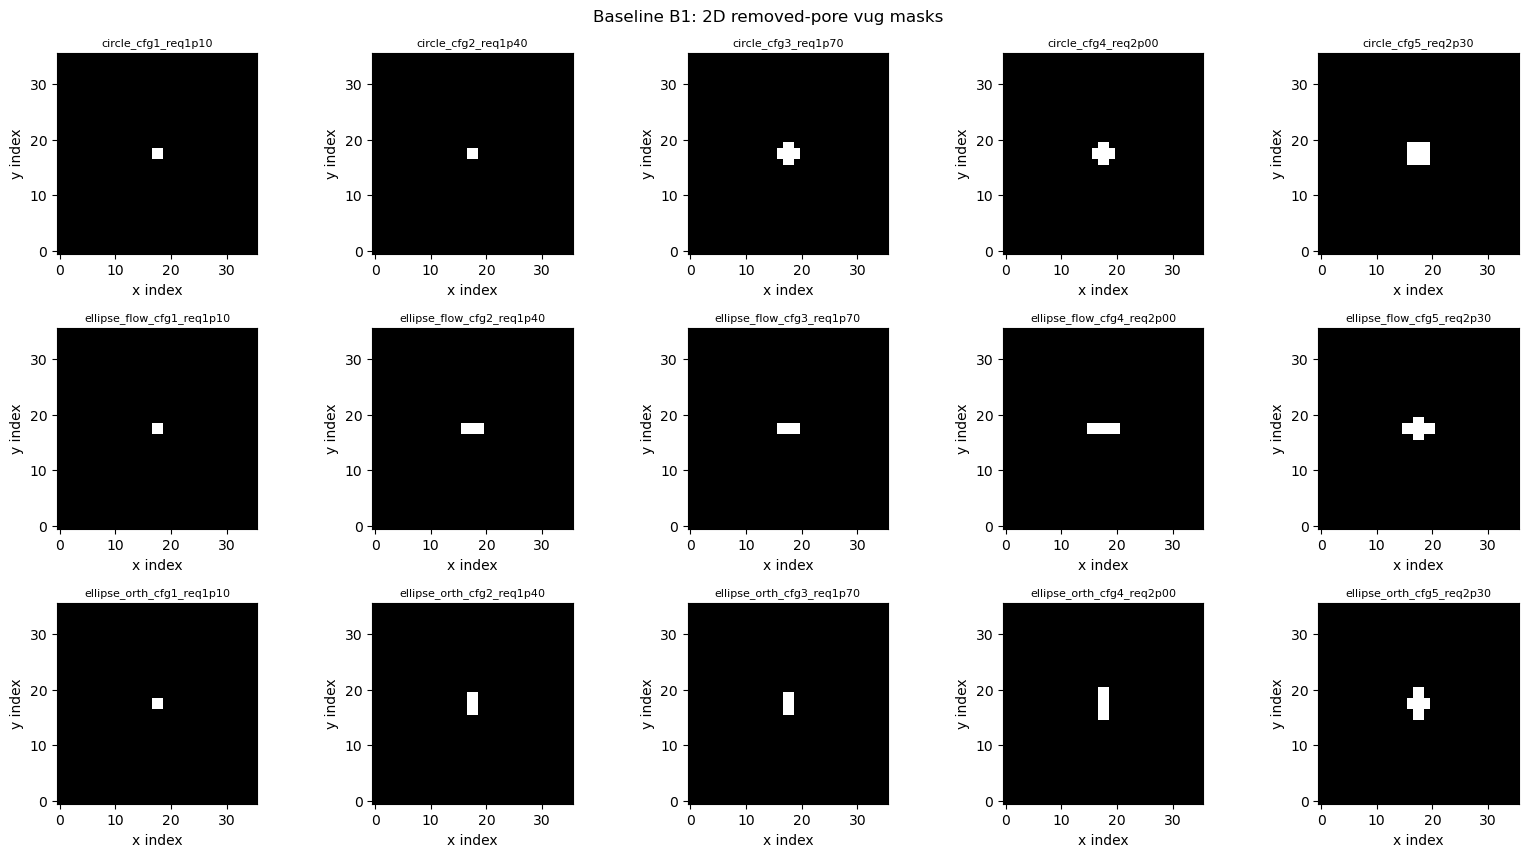

In [20]:
nx, ny = MESH_SHAPE_2D
preview_cases = sorted(mask_preview.keys())
ncols = 5
nrows = (len(preview_cases) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(3.2 * ncols, 2.9 * nrows), squeeze=False
)

for idx, case_name in enumerate(preview_cases):
    ax = axes[idx // ncols, idx % ncols]
    mask2d = np.asarray(mask_preview[case_name], dtype=bool).reshape(nx, ny)
    ax.imshow(mask2d.T, origin="lower", cmap="gray")
    ax.set_title(case_name.replace("B1_", ""), fontsize=8)
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")

for idx in range(len(preview_cases), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

fig.suptitle("Baseline B1: 2D removed-pore vug masks")
plt.tight_layout()
plt.show()

## Aggregate response across baselines

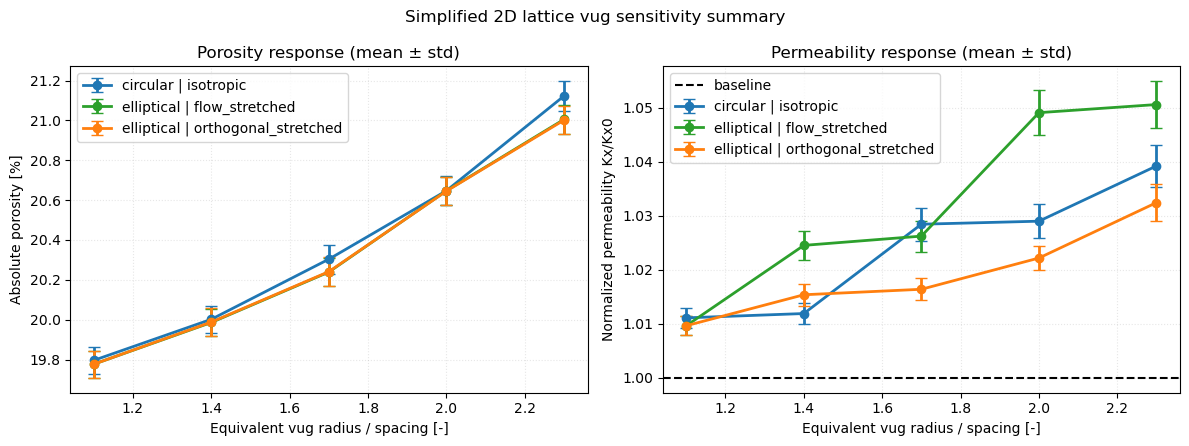

In [21]:
aggregated: dict[tuple[str, str, int], dict[str, object]] = {}
for row in all_results:
    if str(row["family"]) == "baseline":
        continue
    key = (str(row["family"]), str(row["orientation"]), int(row["config_index"]))
    if key not in aggregated:
        aggregated[key] = {
            "equivalent_radius_spacing": float(row["equivalent_radius_spacing"]),
            "k_ratio": [],
            "phi_abs": [],
        }
    aggregated[key]["k_ratio"].append(float(row["K_ratio_to_baseline"]))
    aggregated[key]["phi_abs"].append(float(row["phi_abs"]))

orientation_groups = [
    ("circular", "isotropic", "tab:blue"),
    ("elliptical", "flow_stretched", "tab:green"),
    ("elliptical", "orthogonal_stretched", "tab:orange"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for family, orientation, color in orientation_groups:
    keys = sorted(
        [k for k in aggregated if k[0] == family and k[1] == orientation],
        key=lambda k: k[2],
    )
    if not keys:
        continue

    r_eq = np.array(
        [aggregated[k]["equivalent_radius_spacing"] for k in keys], dtype=float
    )
    k_mean = np.array([np.mean(aggregated[k]["k_ratio"]) for k in keys], dtype=float)
    k_std = np.array([np.std(aggregated[k]["k_ratio"]) for k in keys], dtype=float)
    phi_mean = 100.0 * np.array(
        [np.mean(aggregated[k]["phi_abs"]) for k in keys], dtype=float
    )
    phi_std = 100.0 * np.array(
        [np.std(aggregated[k]["phi_abs"]) for k in keys], dtype=float
    )

    label = f"{family} | {orientation}"
    axes[0].errorbar(
        r_eq,
        phi_mean,
        yerr=phi_std,
        marker="o",
        linewidth=2,
        capsize=4,
        color=color,
        label=label,
    )
    axes[1].errorbar(
        r_eq,
        k_mean,
        yerr=k_std,
        marker="o",
        linewidth=2,
        capsize=4,
        color=color,
        label=label,
    )

axes[0].set_xlabel("Equivalent vug radius / spacing [-]")
axes[0].set_ylabel("Absolute porosity [%]")
axes[0].set_title("Porosity response (mean ± std)")
axes[0].grid(alpha=0.3, linestyle=":")
axes[0].legend()

axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.5, label="baseline")
axes[1].set_xlabel("Equivalent vug radius / spacing [-]")
axes[1].set_ylabel(f"Normalized permeability K{FLOW_AXIS}/K{FLOW_AXIS}0")
axes[1].set_title("Permeability response (mean ± std)")
axes[1].grid(alpha=0.3, linestyle=":")
axes[1].legend()

fig.suptitle("Simplified 2D lattice vug sensitivity summary")
plt.tight_layout()
plt.show()

## K/K0 frequency distributions by equivalent radius

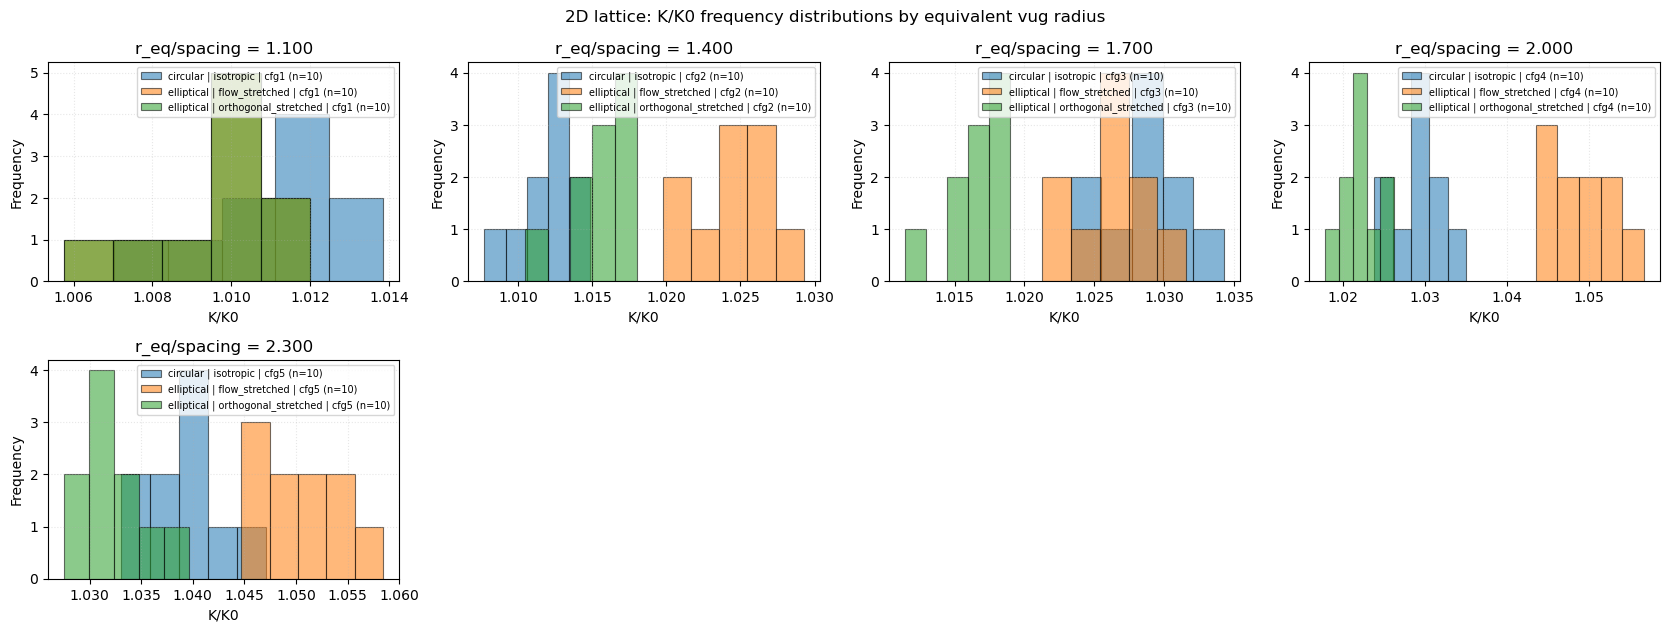

In [22]:
kk0_by_radius_and_config: dict[float, dict[str, list[float]]] = {}
for row in all_results:
    if str(row["family"]) == "baseline":
        continue
    r_key = round(float(row["equivalent_radius_spacing"]), 3)
    cfg_label = (
        f"{row['family']} | {row['orientation']} | cfg{int(row['config_index'])}"
    )

    if r_key not in kk0_by_radius_and_config:
        kk0_by_radius_and_config[r_key] = {}
    if cfg_label not in kk0_by_radius_and_config[r_key]:
        kk0_by_radius_and_config[r_key][cfg_label] = []
    kk0_by_radius_and_config[r_key][cfg_label].append(float(row["K_ratio_to_baseline"]))

radius_keys = sorted(kk0_by_radius_and_config.keys())
ncols_hist = min(4, max(1, len(radius_keys)))
nrows_hist = (len(radius_keys) + ncols_hist - 1) // ncols_hist
fig, axes = plt.subplots(
    nrows_hist,
    ncols_hist,
    figsize=(4.2 * ncols_hist, 3.2 * nrows_hist),
    squeeze=False,
)

for ax, radius_key in zip(axes.flat, radius_keys):
    cfg_map = kk0_by_radius_and_config[radius_key]
    for cfg_label, values in sorted(cfg_map.items()):
        vals = np.asarray(values, dtype=float)
        if vals.size == 0:
            continue
        bins = np.histogram_bin_edges(vals, bins=min(10, max(5, vals.size // 2)))
        if np.unique(bins).size < 2:
            center = float(vals.mean())
            bins = np.array([center - 0.03, center + 0.03], dtype=float)
        ax.hist(
            vals,
            bins=bins,
            alpha=0.55,
            edgecolor="black",
            linewidth=0.8,
            label=f"{cfg_label} (n={vals.size})",
        )

    ax.set_title(f"r_eq/spacing = {radius_key:.3f}")
    ax.set_xlabel("K/K0")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(fontsize=7)

for ax in axes.flat[len(radius_keys) :]:
    ax.axis("off")

fig.suptitle("2D lattice: K/K0 frequency distributions by equivalent vug radius")
plt.tight_layout()
plt.show()

## Interpretation and limitations

- This 2D study is computationally lighter and easier to inspect than 3D.
- Relative trends are useful for sensitivity screening.
- Absolute values are model dependent (geometry assumptions + conductance model).
